# Introducción al Proyecto: Predicción de Tasa de Clics (CTR) en Publicidad Móvil  

El proyecto Avazu Click-Through Rate Prediction aborda uno de los grandes desafíos de la publicidad digital masiva: estimar la probabilidad de que un usuario haga clic en un anuncio móvil (click = 1) o no (click = 0) a partir de un conjunto de datos de más de 40 millones de registros. Para resolver esta tarea de clasificación supervisada, se construirá y optimizará un Perceptrón Multicapa (MLP / Red Neuronal Multicapa), contrastando técnicamente el rendimiento y los tiempos de cómputo entre un enfoque local sobre una muestra de 1 millón de datos en scikit-learn y un procesamiento distribuido a escala completa en PySpark. Finalmente, el trabajo integra la técnica de explicabilidad LIME (Local Interpretable Model-agnostic Explanations) para auditar las predicciones individuales del modelo, identificando qué características contextuales y del dispositivo influyen en la decisión final de la red neuronal.  

## Objetivo General 

Desarrollar un pipeline completo de Machine Learning supervisado utilizando un Perceptrón Multicapa (MLP / Red Neuronal Multicapa) para clasificar si una impresión resultará en clic (1) o no (0).  

### Objetivos Especificos  

- Preparar los datos masivos en PySpark mediante análisis exploratorio, transformación de variables temporales y preparación de muestras para el entrenamiento.
- Entrenar y optimizar modelos MLP en PySpark y scikit-learn, comparando su rendimiento (ROC AUC, F1-score) y tiempos de cómputo.
- Interpretar las predicciones individuales del modelo usando LIME para identificar las variables de mayor impacto en los casos clasificados erróneamente.

# Análisis Exploratorio de Datos  

Inicialmente se procederá con el análisis del dataset y sus características, junto al estudio de las variables consideradas más relevantes para el desarrollo del modelo. Este Dataset tiene un aproximado de 40 millones de datos, por tanto, para el siguiente análisis se usará PySpark y el conjunto de test ya establecido.   

Esta es una base de datos proveniente de la competencia Avazu Click-Through Rate Prediction alojada en la plataforma Kaggle. Contiene información recopilada durante 10 días sobre impresiones de publicidad en dispositivos móviles, registrando si el usuario interactuó con el anuncio (click = 1) o no (click = 0) para evaluar el rendimiento de los modelos en un escenario real de publicidad digital.   

- **Fuente de los datos: Kaggle** https://www.kaggle.com/competitions/avazu-ctr-prediction/data  

## Descripción de los campos principales:

- id: identificador del anuncio
- click: indicador de si hubo clic
- hour: hora de la impresión del anuncio (formato YYMMDDHH)
- C1: variable categórica anonimizada
- banner_pos
- site_id, site_domain, site_category
- app_id, app_domain, app_category
- device_id, device_ip, device_model
- device_type, device_conn_type
- C14–C21: variables categóricas anónimas

## Carga de datos

In [1]:
from pyspark.sql import SparkSession

In [2]:
import pyspark.sql.functions as F
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import os

In [3]:
# Carga del Dataset 
spark = SparkSession.builder \
    .appName("Avazu_EDA") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "16g") \
    .config("spark.driver.maxResultSize", "0") \
    .config("spark.sql.shuffle.partitions", "32") \
    .getOrCreate()
df_train = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("../data/train.csv")
df_test = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("../data/test.csv")


**Visualización inicial del dataset**

In [4]:
df_train.show(10)

+--------------------+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
|                  id|click|    hour|  C1|banner_pos| site_id|site_domain|site_category|  app_id|app_domain|app_category|device_id|device_ip|device_model|device_type|device_conn_type|  C14|C15|C16| C17|C18|C19|   C20|C21|
+--------------------+-----+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
| 1000009418151094273|    0|14102100|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    07d7df22| a99f214a| ddd2926e|    44956a24|          1|               2|15706|320| 50|1722|  0| 35|    -1| 79|
|10000169349117863715|    0|14102100|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    

In [5]:
df_test.show(10)

+--------------------+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
|                  id|    hour|  C1|banner_pos| site_id|site_domain|site_category|  app_id|app_domain|app_category|device_id|device_ip|device_model|device_type|device_conn_type|  C14|C15|C16| C17|C18|C19|   C20|C21|
+--------------------+--------+----+----------+--------+-----------+-------------+--------+----------+------------+---------+---------+------------+-----------+----------------+-----+---+---+----+---+---+------+---+
|10000174058809263569|14103100|1005|         0|235ba823|   f6ebf28e|     f028772b|ecad2386|  7801e8d9|    07d7df22| a99f214a| 69f45779|    0eb711ec|          1|               0| 8330|320| 50| 761|  3|175|100075| 23|
|10000182526920855428|14103100|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    07d7df22| a99f214a| e8d44657| 

## Análisis de la variable de respuesta (Click)  

Primero se hace un análisis del conteo total de cada categoria (click=1 y no click=0 ), frecuencia y proporción.

In [6]:
# Total de registros en train
total_rows = df_train.count()

# Conteo y distribución porcentual
click_dist = df_train.groupBy("click") \
    .agg(
        F.count("*").alias("conteo"),
        (F.count("*") / total_rows * 100).alias("porcentaje")
    ) \
    .withColumn("porcentaje", F.round("porcentaje", 2))

click_dist.show()

+-----+--------+----------+
|click|  conteo|porcentaje|
+-----+--------+----------+
|    1| 6865066|     16.98|
|    0|33563901|     83.02|
+-----+--------+----------+



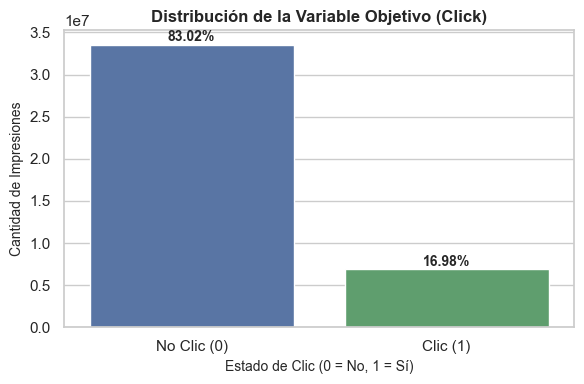

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertir la agregación de PySpark a Pandas DataFrame
pdf_click = click_dist.toPandas()

# Configuración del estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# 2. Crear el gráfico de barras
ax = sns.barplot(
    data=pdf_click, 
    x="click", 
    y="conteo", 
    palette=["#4C72B0", "#55A868"]
)

# 3. Personalización del gráfico
plt.title("Distribución de la Variable Objetivo (Click)", fontsize=12, fontweight="bold")
plt.xlabel("Estado de Clic (0 = No, 1 = Sí)", fontsize=10)
plt.ylabel("Cantidad de Impresiones", fontsize=10)
plt.xticks(ticks=[0, 1], labels=["No Clic (0)", "Clic (1)"])

# 4. Asignar el porcentaje correcto a cada posición
for _, row in pdf_click.iterrows():
    posicion_x = int(row["click"])  # Usar el valor real de click (0 o 1) como coordenada X
    porcentaje = row["porcentaje"]
    conteo = row["conteo"]
    
    ax.text(
        posicion_x, 
        conteo + (total_rows * 0.01), 
        f"{porcentaje}%", 
        ha="center", 
        fontsize=10, 
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

El análisis sobre el conjunto de datos de entrenamiento evidencia un desbalance de clases significativo, característico de los problemas de predicción de tasa de clics (CTR) en publicidad digital. Del total de impresiones registradas, aproximadamente 33.5 millones (83.02%) corresponden a interacciones donde el usuario no hizo clic (click = 0), mientras que únicamente 6.8 millones (16.98%) resultaron en un clic efectivo (click = 1), estableciendo la tasa global de conversión del dataset en un 16.98%.  

Este desequilibrio implica que un modelo ingenuo que prediga siempre la clase mayoritaria alcanzaría un Accuracy del 83.02% sin aportar ningún valor predictivo real. Por lo tanto, durante el modelado con el Perceptrón Multicapa (MLP) será fundamental descartar el Accuracy como métrica principal y priorizar ROC AUC, Precision, Recall y F1-Score. Asimismo, esta desproporción justifica la evaluación de técnicas de ponderación de clases (class weighting) o balanceo en las fases de preprocesamiento para evitar que la red neuronal se sesgue hacia la clase negativa. 

## Tipos de Datos  

In [8]:
df_test.printSchema()

root
 |-- id: decimal(20,0) (nullable = true)
 |-- hour: integer (nullable = true)
 |-- C1: integer (nullable = true)
 |-- banner_pos: integer (nullable = true)
 |-- site_id: string (nullable = true)
 |-- site_domain: string (nullable = true)
 |-- site_category: string (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_domain: string (nullable = true)
 |-- app_category: string (nullable = true)
 |-- device_id: string (nullable = true)
 |-- device_ip: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: integer (nullable = true)
 |-- device_conn_type: integer (nullable = true)
 |-- C14: integer (nullable = true)
 |-- C15: integer (nullable = true)
 |-- C16: integer (nullable = true)
 |-- C17: integer (nullable = true)
 |-- C18: integer (nullable = true)
 |-- C19: integer (nullable = true)
 |-- C20: integer (nullable = true)
 |-- C21: integer (nullable = true)



Los dataset las variables se clasifican de la siguiente manera:
- id: Decimal(20,0)
- hour: Integer
- C1: Integer
- banner_pos: Integer
- site_id: String
- site_domain: String
- site_category: String
- app_id: String
- app_domain: String
- app_category: String
- device_id: String
- device_ip: String
- device_model: String
- device_type: Integer
- device_conn_type: Integer
- C14: Integer
- C15: Integer
- C16: Integer
- C17: Integer
- C18: Integer
- C19: Integer
- C20: Integer
- C21: Integer

Nótese que las variables categóricas son convertidas a enteros, tal es el caso C1, C14, etc. Por tanto, es necesario hacer un análisis más exhaustivo de cada característica.  

## Identificación de valores faltantes  



In [9]:
# 1. Calcular conteo de nulos por columna en una sola pasada eficiente
total_rows = df_train.count()

null_exprs = [
    F.count(F.when(F.col(c).isNull() | F.isnan(c), c)).alias(c) 
    if dtype in ["double", "float"] 
    else F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c, dtype in df_train.dtypes
]

null_counts_dict = df_train.select(null_exprs).collect()[0].asDict()

# 2. Construir DataFrame explicativo
null_summary = []
for col_name, null_count in null_counts_dict.items():
    null_pct = (null_count / total_rows) * 100
    null_summary.append({
        "Variable": col_name,
        "Cantidad_Nulos": null_count,
        "Porcentaje_Nulos (%)": round(null_pct, 4)
    })

df_nulls_summary = pd.DataFrame(null_summary)

# Mostrar el resultado tabular
print(f"Total de registros analizados: {total_rows:,}")
df_nulls_summary

Total de registros analizados: 40,428,967


,Variable,Cantidad_Nulos,Porcentaje_Nulos (%)
0,id,0,0.0
1,click,0,0.0
2,hour,0,0.0
3,C1,0,0.0
4,banner_pos,0,0.0
5,site_id,0,0.0
6,site_domain,0,0.0
7,site_category,0,0.0
8,app_id,0,0.0
9,app_domain,0,0.0


Gracias a lo anterior, se puede observar que no existen valores faltantes del tipo null o NaN. Sin embargo, es muy inusual este comportamiento en dataset reales, por tanto, en análisis posteriores se analizará cada variable para saber su comportamiento y si los valores nulos están registrados con algún valor como negativos o cadenas.  

## Análisis de cardinalidad de las variables categóricas  

Se realizará el siguiente análisis con el fin de evaluar la cantidad de valores únicos que posee cada variable categórica dentro de un conjunto de datos. Su objetivo principal es clasificar las variables en baja cardinalidad (pocas categorías, como el tipo de dispositivo) y alta cardinalidad (miles o millones de IDs únicos, como el identificador del dispositivo); con el fin de definir más adelante la estrategia de codificación adecuada, tal como One-Hot-Encoding o agrupamiento con Top-K.  

In [10]:
# 1. Definir la lista de variables categóricas del dataset
cat_cols = [
    "site_id", "site_domain", "site_category", 
    "app_id", "app_domain", "app_category", 
    "device_id", "device_ip", "device_model", 
    "device_type", "device_conn_type", "banner_pos", "C1",
    "C14","C15", "C16","C17","C18","C19","C20","C21"
]

# 2. Calcular la cardinalidad (valores únicos) en PySpark en un solo pase
cardinality_exprs = [F.countDistinct(c).alias(c) for c in cat_cols]
cardinality_dict = df_train.select(cardinality_exprs).collect()[0].asDict()

# 3. Formatear y ordenar los resultados en un DataFrame de Pandas
df_cardinality = pd.DataFrame(
    list(cardinality_dict.items()), 
    columns=["Variable", "Valores_Unicos"]
).sort_values(by="Valores_Unicos", ascending=False).reset_index(drop=True)

# Agregar clasificación según el nivel de cardinalidad
df_cardinality["Tipo_Cardinalidad"] = df_cardinality["Valores_Unicos"].apply(
    lambda x: "Alta (>1000)" if x > 1000 else ("Media (10-1000)" if x >= 10 else "Baja (<10)")
)

df_cardinality

,Variable,Valores_Unicos,Tipo_Cardinalidad
0,device_ip,6729486,Alta (>1000)
1,device_id,2686408,Alta (>1000)
2,app_id,8552,Alta (>1000)
3,device_model,8251,Alta (>1000)
4,site_domain,7745,Alta (>1000)
5,site_id,4737,Alta (>1000)
6,C14,2626,Alta (>1000)
7,app_domain,559,Media (10-1000)
8,C17,435,Media (10-1000)
9,C20,172,Media (10-1000)


Existen 14 variables categóricas que necesitan más cuidado por su alta y media cardinalidad, por lo cual, en la transformación y preprocesamiento de los datos se realiarán diferentes técnicas para mitigar los efectos la cardinalidad.  

## Transformación de la variable Hour

Se desea transformar la variable "hour" en nuevas características temporales (día, hora y franja horaria), dado que, por si sola la variable no da mucha información a la red neuronal haciendola más compleja. Por tanto, se da paso a la siguiente transformación: 

In [11]:
unique_hour = df_train.select(F.countDistinct("hour")).collect()[0][0]
print(f"Total de horas distintas: {unique_hour}")

Total de horas distintas: 240


Existen 140 categorías diferentes en "hour". 

In [12]:
# 1. Convertir 'hour' a String para extracción de caracteres
df_train_1 = df_train.withColumn("hour_str", F.col("hour").cast("string"))

# 2. Extraer día, hora del día y construir la franja horaria directamente
df_transformed = df_train_1 \
    .withColumn("day", F.substring("hour_str", 5, 2).cast("integer")) \
    .withColumn("hour_of_day", F.substring("hour_str", 7, 2).cast("integer")) \
    .withColumn(
        "franja_horaria",
        F.when((F.col("hour_of_day") >= 0) & (F.col("hour_of_day") < 6), "Madrugada")
         .when((F.col("hour_of_day") >= 6) & (F.col("hour_of_day") < 12), "Mañana")
         .when((F.col("hour_of_day") >= 12) & (F.col("hour_of_day") < 18), "Tarde")
         .otherwise("Noche")
    ) \
    .drop("hour_str")

# Mostrar las columnas seleccionadas
df_transformed.select("hour", "day", "hour_of_day", "franja_horaria").show(5)

# transformación para df_test

df_train_2 = df_test.withColumn("hour_str", F.col("hour").cast("string"))
df_transformed_test = df_train_1 \
    .withColumn("day", F.substring("hour_str", 5, 2).cast("integer")) \
    .withColumn("hour_of_day", F.substring("hour_str", 7, 2).cast("integer")) \
    .withColumn(
        "franja_horaria",
        F.when((F.col("hour_of_day") >= 0) & (F.col("hour_of_day") < 6), "Madrugada")
         .when((F.col("hour_of_day") >= 6) & (F.col("hour_of_day") < 12), "Mañana")
         .when((F.col("hour_of_day") >= 12) & (F.col("hour_of_day") < 18), "Tarde")
         .otherwise("Noche")
    ) \
    .drop("hour_str")

+--------+---+-----------+--------------+
|    hour|day|hour_of_day|franja_horaria|
+--------+---+-----------+--------------+
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
|14102100| 21|          0|     Madrugada|
+--------+---+-----------+--------------+
only showing top 5 rows



In [13]:
unique_dias = df_transformed.select(F.countDistinct("day")).collect()[0][0]
print(f"Total de días distintos: {unique_dias}")

Total de días distintos: 10


In [14]:
unique_hour_of_day = df_transformed.select(F.countDistinct("hour_of_day")).collect()[0][0]
print(f"Total de horas distintas: {unique_hour_of_day}")

Total de horas distintas: 24


In [15]:
unique_franja_horaria = df_transformed.select(F.countDistinct("franja_horaria")).collect()[0][0]
print(f"Total de franjas horarias: {unique_franja_horaria}")

Total de franjas horarias: 4


Descomponer la variable hour en day, hour_of_day y franja_horaria transforma un entero continuo y rígido (YYMMDDHH) en señales temporales interpretables para el Perceptrón Multicapa. Esto elimina discontinuidades numéricas falsas (como el salto entre un día y otro) y permite al modelo capturar de forma directa los patrones de comportamiento humano a lo largo de las rutinas diarias y los días de la semana, reduciendo además el ruido y la dimensionalidad de los datos.  

### Gráfico de las variables creadas  

**Histrograma de la variable Día y Hora del día**

In [16]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# 1. Extraer la muestra
df_time_sample = df_transformed.select("day", "hour_of_day").sample(withReplacement=False, fraction=0.05, seed=42).toPandas()

# 2. Agrupar conteos para alimentar el gráfico interactivo
df_hour_counts = df_time_sample["hour_of_day"].value_counts().reset_index()
df_hour_counts.columns = ["hour_of_day", "count"]
df_hour_counts = df_hour_counts.sort_values("hour_of_day")

df_day_counts = df_time_sample["day"].value_counts().reset_index()
df_day_counts.columns = ["day", "count"]
df_day_counts = df_day_counts.sort_values("day")

# 3. Crear figura interactiva con subplots
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Distribución por Hora del Día (0 - 23)", "Distribución por Día del Mes")
)

# Barra para Hora del Día
fig.add_trace(
    go.Bar(
        x=df_hour_counts["hour_of_day"], 
        y=df_hour_counts["count"],
        marker_color="#4C72B0",
        hovertemplate="<b>Hora del día:</b> %{x}<br><b>Impresiones:</b> %{y:,.0f}<extra></extra>"
    ),
    row=1, col=1
)

# Barra para Día del Mes
fig.add_trace(
    go.Bar(
        x=df_day_counts["day"], 
        y=df_day_counts["count"],
        marker_color="#55A868",
        hovertemplate="<b>Día de octubre:</b> %{x}<br><b>Impresiones:</b> %{y:,.0f}<extra></extra>"
    ),
    row=1, col=2
)

# 4. Ajustes de layout
fig.update_layout(
    height=400, 
    width=900, 
    showlegend=False,
    title_text="Análisis Temporal de Impresiones (Muestra)"
)

fig.update_xaxes(title_text="Hora del Día", row=1, col=1, dtick=1)
fig.update_yaxes(title_text="Frecuencia (Impresiones)", row=1, col=1)

fig.update_xaxes(title_text="Día del Mes (Octubre)", row=1, col=2, dtick=1)
fig.update_yaxes(title_text="Frecuencia (Impresiones)", row=1, col=2)

fig.show()

**Diagrama de barras de la variable Franja Horaria**

c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


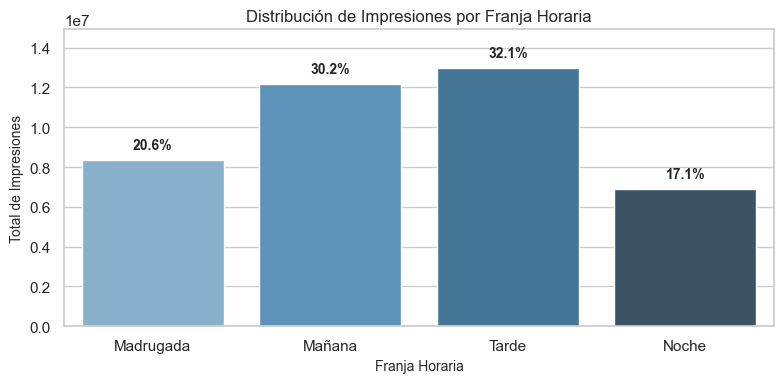

In [17]:
# 1. Agrupar y contar en PySpark (eficiente para 40M de filas)
df_franja = df_transformed.groupBy("franja_horaria").count().toPandas()

# 2. Ordenar lógicamente las franjas
orden_franjas = ["Madrugada", "Mañana", "Tarde", "Noche"]
df_franja['franja_horaria'] = pd.Categorical(df_franja['franja_horaria'], categories=orden_franjas, ordered=True)
df_franja = df_franja.sort_values('franja_horaria')

# 3. Calcular porcentaje total
total_impressions = df_franja['count'].sum()
df_franja['porcentaje'] = (df_franja['count'] / total_impressions) * 100

# 4. Graficar
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df_franja, x="franja_horaria", y="count", palette="Blues_d")

# Agregar etiquetas de porcentaje sobre cada barra
for i, row in df_franja.reset_index(drop=True).iterrows():
    ax.text(i, row['count'] + (total_impressions * 0.01), f"{row['porcentaje']:.1f}%", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Distribución de Impresiones por Franja Horaria", fontsize=12)
plt.xlabel("Franja Horaria", fontsize=10)
plt.ylabel("Total de Impresiones", fontsize=10)
plt.ylim(0, df_franja['count'].max() * 1.15)  # Espacio para las etiquetas
plt.tight_layout()
plt.show()

## Gráfico de frecuencia de las principales variables Categóricas  

En este apartado se realizarán los correspondientes gráficos a las variables que presentan una cardinalidad baja, de lo contrario, los gráficos serán poco interpretables por el gran número de categorías que tienen 14 variables antes mencionadas. De esta manera, se harán los siguientes gráficos: 

### C16 

In [18]:
# 1. Agrupar y contar frecuencias directamente en PySpark (eficiente para 40M)
df__counts = df_transformed.groupBy("C16").count() \
    .orderBy("count", ascending=False) \
    .toPandas()

# Convertir C16 a string para forzar tratamiento categórico en el eje X
df__counts["C16"] = df__counts["C16"].astype(str)

# Calcular porcentaje del total de impresiones
total_impressions = df__counts["count"].sum()
df__counts["porcentaje"] = (df__counts["count"] / total_impressions) * 100

# 2. Crear gráfico de barras interactivo
fig = px.bar(
    df__counts,
    x="C16",
    y="count",
    text=df__counts["porcentaje"].apply(lambda x: f"{x:.1f}%"),
    title="Distribución de Frecuencia para C16",
    labels={"C16": "Valor de C16", "count": "Total de Impresiones"},
    color_discrete_sequence=["#2B5B84"]
)

# 3. Personalizar interacción (hover/tooltip) y diseño
fig.update_traces(
    textposition="outside",
    hovertemplate="<b>Altura (C16):</b> %{x} px<br>" +
                  "<b>Impresiones:</b> %{y:,.0f}<br>" +
                  "<b>Porcentaje:</b> %{text}<extra></extra>"
)

fig.update_layout(
    height=450,
    width=750,
    xaxis_type="category",
    yaxis_title="Cantidad de Impresiones",
    xaxis_title="Categoría de C16",
    title_x=0.5,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

La variable C16 es un atributo categórico anónimo de baja cardinalidad. Al analizar su distribución de frecuencias, se observa una fuerte concentración de impresiones en solo unas pocas categorías específicas, lo que la convierte en una candidata ideal para la transformación mediante One-Hot Encoding directo sin riesgo de dispersión de datos.  

### C15  

In [19]:
# 1. Agrupar y contar frecuencias directamente en PySpark (eficiente para 40M)
df__counts = df_transformed.groupBy("C15").count() \
    .orderBy("count", ascending=False) \
    .toPandas()
df__counts["C15"] = df__counts["C15"].astype(str)

# Calcular porcentaje del total de impresiones
total_impressions = df__counts["count"].sum()
df__counts["porcentaje"] = (df__counts["count"] / total_impressions) * 100

# 2. Crear gráfico de barras interactivo
fig = px.bar(
    df__counts,
    x="C15",
    y="count",
    text=df__counts["porcentaje"].apply(lambda x: f"{x:.1f}%"),
    title="Distribución de Frecuencia para C15",
    labels={"C15": "Valor de C15", "count": "Total de Impresiones"},
    color_discrete_sequence=["#2B5B84"]
)

# 3. Personalizar interacción (hover/tooltip) y diseño
fig.update_traces(
    textposition="outside",
    hovertemplate="<b>Altura (C15):</b> %{x} px<br>" +
                  "<b>Impresiones:</b> %{y:,.0f}<br>" +
                  "<b>Porcentaje:</b> %{text}<extra></extra>"
)

fig.update_layout(
    height=450,
    width=750,
    xaxis_type="category",
    yaxis_title="Cantidad de Impresiones",
    xaxis_title="Categoría de C15",
    title_x=0.5,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

El análisis de frecuencia para la variable categórica anónima C15 muestra un sesgo pronunciado hacia un número reducido de valores, donde la categoría principal representa el 93.3% de las impresiones totales y una segunda categoría abarca el 5.8%. Dado que posee únicamente 8 niveles únicos y el 99.1% de la información se concentra en solo dos de ellos, esta variable presenta una baja cardinalidad idónea para aplicar One-Hot Encoding directo o una agrupación Top-K, permitiendo al modelo capturar la señal dominante sin incorporar dispersión innecesaria en la capa de entrada.  

### C1  

In [20]:
# 1. Agrupar y contar frecuencias directamente en PySpark (eficiente para 40M)
df__counts = df_transformed.groupBy("C1").count() \
    .orderBy("count", ascending=False) \
    .toPandas()
df__counts["C1"] = df__counts["C1"].astype(str)

# Calcular porcentaje del total de impresiones
total_impressions = df__counts["count"].sum()
df__counts["porcentaje"] = (df__counts["count"] / total_impressions) * 100

# 2. Crear gráfico de barras interactivo
fig = px.bar(
    df__counts,
    x="C1",
    y="count",
    text=df__counts["porcentaje"].apply(lambda x: f"{x:.1f}%"),
    title="Distribución de Frecuencia para C1",
    labels={"C1": "Valor de C1", "count": "Total de Impresiones"},
    color_discrete_sequence=["#2B5B84"]
)

# 3. Personalizar interacción (hover/tooltip) y diseño
fig.update_traces(
    textposition="outside",
    hovertemplate="<b>Altura (C1):</b> %{x} px<br>" +
                  "<b>Impresiones:</b> %{y:,.0f}<br>" +
                  "<b>Porcentaje:</b> %{text}<extra></extra>"
)

fig.update_layout(
    height=450,
    width=750,
    xaxis_type="category",
    yaxis_title="Cantidad de Impresiones",
    xaxis_title="Categoría de C1",
    title_x=0.5,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

El análisis de frecuencia para la variable categórica anónima C1 revela una severa asimetría en su distribución, donde la categoría principal (1005) abarca el 91.9% del tráfico y solo tres valores explican el 99.6% del total. Al contar con apenas 7 categorías únicas, esta condición de baja cardinalidad permite aplicar un One-Hot Encoding directo o un agrupamiento Top-K (K=3) para simplificar las frecuencias marginales, garantizando una entrada eficiente y libre de ruido para el Perceptrón Multicapa.  

### banner_pos  

In [21]:
# 1. Agrupar y contar frecuencias directamente en PySpark (eficiente para 40M)
df__counts = df_transformed.groupBy("banner_pos").count() \
    .orderBy("count", ascending=False) \
    .toPandas()
df__counts["banner_pos"] = df__counts["banner_pos"].astype(str)

# Calcular porcentaje del total de impresiones
total_impressions = df__counts["count"].sum()
df__counts["porcentaje"] = (df__counts["count"] / total_impressions) * 100

# 2. Crear gráfico de barras interactivo
fig = px.bar(
    df__counts,
    x="banner_pos",
    y="count",
    text=df__counts["porcentaje"].apply(lambda x: f"{x:.1f}%"),
    title="Distribución de Frecuencia para banner_pos",
    labels={"banner_pos": "Valor de banner_pos", "count": "Total de Impresiones"},
    color_discrete_sequence=["#2B5B84"]
)

# 3. Personalizar interacción (hover/tooltip) y diseño
fig.update_traces(
    textposition="outside",
    hovertemplate="<b>Altura (banner_pos):</b> %{x} px<br>" +
                  "<b>Impresiones:</b> %{y:,.0f}<br>" +
                  "<b>Porcentaje:</b> %{text}<extra></extra>"
)

fig.update_layout(
    height=450,
    width=750,
    xaxis_type="category",
    yaxis_title="Cantidad de Impresiones",
    xaxis_title="Categoría de C1",
    title_x=0.5,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

El análisis de frecuencia para la variable banner_pos muestra una fuerte concentración en solo dos valores, donde la categoría 0 domina con el 72.0% de las impresiones y la 1 abarca el 27.8%, sumando entre ambas el 99.8% del tráfico total. Al contar únicamente con 7 niveles únicos y una presencia casi nula en las categorías restantes (7, 2, 4, 5, 3), esta condición de baja cardinalidad justifica el uso de One-Hot Encoding directo o una agrupación Top-K (K=2) para eliminar la dispersión provocada por las posiciones de ultra-baja frecuencia antes de alimentar el Perceptrón Multicapa.  

### device_type

In [22]:
# 1. Agrupar y contar frecuencias directamente en PySpark (eficiente para 40M)
df__counts = df_transformed.groupBy("device_type").count() \
    .orderBy("count", ascending=False) \
    .toPandas()
df__counts["device_type"] = df__counts["device_type"].astype(str)

# Calcular porcentaje del total de impresiones
total_impressions = df__counts["count"].sum()
df__counts["porcentaje"] = (df__counts["count"] / total_impressions) * 100

# 2. Crear gráfico de barras interactivo
fig = px.bar(
    df__counts,
    x="device_type",
    y="count",
    text=df__counts["porcentaje"].apply(lambda x: f"{x:.1f}%"),
    title="Distribución de Frecuencia para device_type",
    labels={"device_type": "Valor de device_type", "count": "Total de Impresiones"},
    color_discrete_sequence=["#2B5B84"]
)

# 3. Personalizar interacción (hover/tooltip) y diseño
fig.update_traces(
    textposition="outside",
    hovertemplate="<b>Altura (device_type):</b> %{x} px<br>" +
                  "<b>Impresiones:</b> %{y:,.0f}<br>" +
                  "<b>Porcentaje:</b> %{text}<extra></extra>"
)

fig.update_layout(
    height=450,
    width=750,
    xaxis_type="category",
    yaxis_title="Cantidad de Impresiones",
    xaxis_title="Categoría de C1",
    title_x=0.5,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

El análisis de frecuencia para device_type evidencia una marcada asimetría en su distribución, donde la categoría 1 domina con el 92.3% del tráfico y la 0 abarca un 5.5%, acumulando juntas el 97.8% del volumen total. Al contar con solo 5 valores únicos y una representación marginal en las categorías restantes (4 con 1.9%, 5 con 0.3% y 2 con 0.0%), esta condición de baja cardinalidad respalda el uso de One-Hot Encoding directo o una agrupación Top-K (K=2 o K=3) para consolidar los niveles infrecuentes y evitar ruido en la capa de entrada del Perceptrón Multicapa.  

### C18

In [23]:
# 1. Agrupar y contar frecuencias directamente en PySpark (eficiente para 40M)
df__counts = df_transformed.groupBy("C18").count() \
    .orderBy("count", ascending=False) \
    .toPandas()
df__counts["C18"] = df__counts["C18"].astype(str)

# Calcular porcentaje del total de impresiones
total_impressions = df__counts["count"].sum()
df__counts["porcentaje"] = (df__counts["count"] / total_impressions) * 100

# 2. Crear gráfico de barras interactivo
fig = px.bar(
    df__counts,
    x="C18",
    y="count",
    text=df__counts["porcentaje"].apply(lambda x: f"{x:.1f}%"),
    title="Distribución de Frecuencia para C18",
    labels={"C18": "Valor de C18", "count": "Total de Impresiones"},
    color_discrete_sequence=["#2B5B84"]
)

# 3. Personalizar interacción (hover/tooltip) y diseño
fig.update_traces(
    textposition="outside",
    hovertemplate="<b>Altura (C18):</b> %{x} px<br>" +
                  "<b>Impresiones:</b> %{y:,.0f}<br>" +
                  "<b>Porcentaje:</b> %{text}<extra></extra>"
)

fig.update_layout(
    height=450,
    width=750,
    xaxis_type="category",
    yaxis_title="Cantidad de Impresiones",
    xaxis_title="Categoría de C1",
    title_x=0.5,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

El análisis de frecuencia para la variable anónima C18 muestra una distribución más equilibrada entre sus 4 categorías únicas, donde la categoría 0 encabeza con el 41.9% de las impresiones, seguida por la 3 con un 33.8%, la 2 con un 17.6% y la 1 con un 6.7%. Al tratarse de una variable de baja cardinalidad con presencia significativa en cada uno de sus niveles, es una candidata ideal para One-Hot Encoding directo sin necesidad de agrupamientos Top-K, permitiendo al Perceptrón Multicapa capturar la variabilidad de cada categoría sin generar dispersión de datos.  

### device_conn_type  

In [24]:
# 1. Agrupar y contar frecuencias directamente en PySpark (eficiente para 40M)
df__counts = df_transformed.groupBy("device_conn_type").count() \
    .orderBy("count", ascending=False) \
    .toPandas()
df__counts["device_conn_type"] = df__counts["device_conn_type"].astype(str)

# Calcular porcentaje del total de impresiones
total_impressions = df__counts["count"].sum()
df__counts["porcentaje"] = (df__counts["count"] / total_impressions) * 100

# 2. Crear gráfico de barras interactivo
fig = px.bar(
    df__counts,
    x="device_conn_type",
    y="count",
    text=df__counts["porcentaje"].apply(lambda x: f"{x:.1f}%"),
    title="Distribución de Frecuencia para device_conn_type",
    labels={"device_conn_type": "Valor de device_conn_type", "count": "Total de Impresiones"},
    color_discrete_sequence=["#2B5B84"]
)

# 3. Personalizar interacción (hover/tooltip) y diseño
fig.update_traces(
    textposition="outside",
    hovertemplate="<b>Altura (device_conn_type):</b> %{x} px<br>" +
                  "<b>Impresiones:</b> %{y:,.0f}<br>" +
                  "<b>Porcentaje:</b> %{text}<extra></extra>"
)

fig.update_layout(
    height=450,
    width=750,
    xaxis_type="category",
    yaxis_title="Cantidad de Impresiones",
    xaxis_title="Categoría de C1",
    title_x=0.5,
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.show()

El análisis de frecuencia para la variable device_conn_type revela una distribución altamente concentrada en su categoría principal 0, la cual representa el 86.3% del total de impresiones, mientras que las categorías 2 y 3 capturan el 8.2% y 5.4% respectivamente. Al contar con apenas 4 valores únicos y una presencia casi insignificante en la categoría 5 (0.1%), esta baja cardinalidad respalda la aplicación de One-Hot Encoding directo o una consolidación Top-K (K=3) para omitir la categoría marginal, garantizando una representación compacta e informativa en la entrada del Perceptrón Multicapa.  

## Análisis de frecuencia de las demás variables Categóricas  

Ahora se estudiarán las 10 categorías con mayor frecuencia en cada variable categórica con media y alta cardinalidad, con el fin de saber su estructura y formular una solución para el preprocesamiento que se hará. De esta manera, se harán los siguientes gráficos: 

In [25]:
# 1. Obtener el total de registros una sola vez (eficiente en PySpark)
total_records = df_transformed.count()

# 2. Filtrar variables de Media y Alta cardinalidad según tu DataFrame de cardinalidad
cols_to_plot = df_cardinality[
    df_cardinality["Tipo_Cardinalidad"].isin(["Media (10-1000)", "Alta (>1000)"])
]["Variable"].tolist()

# 3. Función para calcular el Top 10 en PySpark y graficar
def plot_top10_category(df_spark, col_name, total_count):
    # Agrupar y extraer las 10 categorías más frecuentes
    df_top10 = df_spark.groupBy(col_name) \
        .agg(F.count("*").alias("count")) \
        .orderBy(F.col("count").desc()) \
        .limit(10) \
        .toPandas()
    
    # Asegurar formato categórico y calcular porcentaje global
    df_top10[col_name] = df_top10[col_name].astype(str)
    df_top10["porcentaje"] = (df_top10["count"] / total_count) * 100
    
    # Generar gráfico interactivo con Plotly
    fig = px.bar(
        df_top10,
        x=col_name,
        y="count",
        text=df_top10["porcentaje"].apply(lambda x: f"{x:.1f}%"),
        title=f"Distribución Top 10 Frecuencias - Variable {col_name}",
        labels={col_name: f"Categoría ({col_name})", "count": "Cantidad de Impresiones"},
        color_discrete_sequence=["#2B5B84"]
    )
    
    fig.update_traces(
        textposition="outside",
        hovertemplate=f"<b>{col_name}:</b> %{{x}}<br>" +
                      "<b>Impresiones:</b> %{y:,.0f}<br>" +
                      "<b>Porcentaje:</b> %{text}<extra></extra>"
    )
    
    fig.update_layout(
        height=450,
        width=750,
        xaxis_type="category",
        yaxis_title="Cantidad de Impresiones",
        xaxis_title=f"Categoría de {col_name}",
        title_x=0.5,
        margin=dict(t=50, b=40, l=40, r=40)
    )
    
    fig.show()

# 4. Generar gráficos para todas las variables identificadas (device_ip, device_id, app_id, etc.)
for col in cols_to_plot:
    plot_top10_category(df_transformed, col, total_records)

Las variables de media y alta cardinalidad presentan desafíos estructurales distintos según el grado de dispersión de sus valores. A continuación se analiza cada grupo y las técnicas de preprocesamiento óptimas para preparar la entrada del Perceptrón Multicapa:   
  
#### **Variables de Alta Cardinalidad (device_ip, device_id, app_id, device_model, site_domain, site_id, C14)**  
Tienen desde miles hasta millones de valores únicos. Atributos como device_ip (6.7M) y device_id (2.6M) presentan una fragmentación extrema donde la mayoría de valores aparecen muy pocas veces. Otras como app_id o site_id concentran un alto porcentaje del tráfico en un Top 10 dominante, seguido de una cola muy larga de valores raros. Por tanto, se usarán las siguientes técnicas recomendadas:
- Eliminación directa: device_ip y device_id deben eliminarse o descartarse para la red neuronal. Generan sobreajuste masivo, agregan millones de dimensiones inútiles mediante One-Hot y impiden la generalización.
- Top-K Grouping ($K \in [10, 50]$) + One-Hot Encoding: Para app_id, site_id, site_domain, device_model y C14. Mantiene explícitas las categorías dominantes (que capturan la mayoría de impresiones) y consolida los miles de valores raros en una categoría residual ("Otros"). 

#### **Variables de Media Cardinalidad (app_domain, C17, C20, C19, C21, app_category, site_category)**  

Tienen entre 10 y 1,000 valores únicos. La señal está distribuida en un número manejable de niveles, aunque siguen existiendo categorías marginales de muy baja frecuencia. Por tanto, se usarán las siguientes técnicas recomendadas:  
- Top-K Grouping moderado ($K \in [10, 30]$) + One-Hot Encoding: Es la mejor estrategia para C17, C20, C19, C21, app_category y site_category. Retiene la gran mayoría de la varianza del tráfico e impide la creación de columnas vacías o ruidosas en el vector de entrada de la red.   
- StringIndexer + One-Hot Encoding directo: Para variables en el rango más bajo como site_category (26) o app_category (36), es totalmente viable aplicar One-Hot completo a todos sus niveles sin agrupar, ya que la dimensionalidad añadida es ligera.  

## Distribución de clics por hora del día  

En este gráfico se analiza la variación temporal del comportamiento del usuario a lo largo de las 24 horas del día (0 a 23), evaluando simultáneamente dos métricas complementarias:

- Volumen absoluto de clics (barras): Representa el conteo total de interacciones exitosas (click = 1) en cada franja horaria. Permite identificar los momentos del día con mayor volumen de actividad y demanda publicitaria.

- Tasa de clics / CTR (línea): Representa la proporción de clics respecto al total de impresiones generadas en esa misma hora. Permite medir la eficiencia real y la propensión del usuario a hacer clic, independientemente del volumen de tráfico.

In [26]:
# 1. Agrupar y calcular métricas por hora en PySpark
df_hourly_ctr = df_transformed.groupBy("hour_of_day") \
    .agg(
        F.count("*").alias("total_impresiones"),
        F.sum("click").alias("total_clics"),
        F.mean("click").alias("ctr")
    ) \
    .orderBy("hour_of_day") \
    .toPandas()

# Convertir la tasa CTR a porcentaje para la visualización
df_hourly_ctr["ctr_pct"] = df_hourly_ctr["ctr"] * 100

# 2. Crear gráfico interactivo con dos ejes Y
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Barra: Volumen de Clics (Eje Y principal)
fig.add_trace(
    go.Bar(
        x=df_hourly_ctr["hour_of_day"],
        y=df_hourly_ctr["total_clics"],
        name="Total Clics",
        marker_color="#4C72B0",
        hovertemplate="<b>Hora:</b> %{x}:00<br><b>Clics:</b> %{y:,.0f}<extra></extra>"
    ),
    secondary_y=False
)

# Línea: Tasa CTR % (Eje Y secundario)
fig.add_trace(
    go.Scatter(
        x=df_hourly_ctr["hour_of_day"],
        y=df_hourly_ctr["ctr_pct"],
        name="Tasa CTR (%)",
        mode="lines+markers",
        line=dict(color="#D55E00", width=3),
        marker=dict(size=7),
        hovertemplate="<b>Hora:</b> %{x}:00<br><b>CTR:</b> %{y:.2f}%<extra></extra>"
    ),
    secondary_y=True
)

# 3. Personalizar diseño y títulos
fig.update_layout(
    title_text="Distribución de Clics y Tasa CTR por Hora del Día (0 - 23)",
    height=480,
    width=850,
    xaxis=dict(title="Hora del Día", dtick=1),
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.6)"),
    margin=dict(t=50, b=40, l=40, r=40)
)

fig.update_yaxes(title_text="Cantidad Total de Clics", secondary_y=False)
fig.update_yaxes(title_text="Tasa de Clics / CTR (%)", secondary_y=True)

fig.show()

El análisis de la distribución de clics por hora del día permite identificar patrones de comportamiento temporal en el tráfico publicitario. Mientras que el volumen absoluto de clics refleja la fluctuación de la demanda y las horas de mayor actividad de los usuarios (alcanzando picos durante las horas laborales y de la tarde), la tasa CTR (%) evidencia variaciones en la propensión al clic según la franja horaria. Esta ciclicidad confirma la relevancia de transformar la hora en representaciones cíclicas (mediante funciones seno/coseno) o codificar la franja horaria para que el Perceptrón Multicapa capture la interacción entre la hora del día y la probabilidad de conversión.  

## Matriz de correlación para variables numéricas creadas  

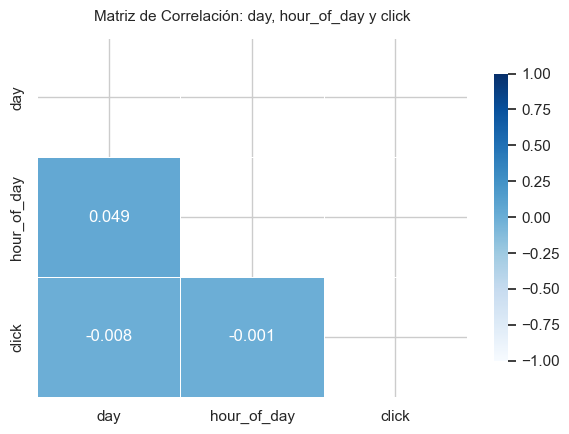

In [27]:
# 1. Definir las dos variables numéricas creadas y el target
time_cols = ["day", "hour_of_day", "click"]

# 2. Ensamblar las columnas en un vector para PySpark
assembler = VectorAssembler(inputCols=time_cols, outputCol="features", handleInvalid="skip")
df_vector = assembler.transform(df_transformed)

# 3. Calcular la matriz de correlación de Pearson en PySpark
matrix = Correlation.corr(df_vector, "features", method="pearson").collect()[0][0]
corr_array = matrix.toArray()

# 4. Convertir la matriz a un DataFrame de Pandas
df_corr = pd.DataFrame(corr_array, index=time_cols, columns=time_cols)

# 5. Visualizar la Matriz de Correlación con Seaborn
plt.figure(figsize=(6, 4.5))
mask = np.triu(np.ones_like(df_corr, dtype=bool))

sns.heatmap(
    df_corr, 
    annot=True, 
    fmt=".3f", 
    cmap="Blues", 
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlación: day, hour_of_day y click", fontsize=11, pad=12)
plt.tight_layout()
plt.show()

La matriz de correlación evalúa la asociación lineal entre las dos variables numéricas extraídas de la marca temporal (day y hour_of_day) y la variable objetivo click. La ausencia de correlación lineal significativa entre los atributos temporales y el target confirma que el comportamiento de los clics no sigue una tendencia lineal a lo largo de los días ni de las horas. Asimismo, la baja correlación entre day y hour_of_day descarta problemas de colinealidad directa entre ambas características, justificando el uso de transformaciones adicionales (como codificación cíclica o de rango) para que el Perceptrón Multicapa pueda capturar sus patrones no lineales.  